In [1]:
import fastf1
import pandas as pd
import numpy as np

# use the data stored locally
fastf1.Cache.enable_cache('../data/raw')

# load the race - bahrain
session = fastf1.get_session(2025, 4, 'R')
session.load()

laps = session.laps

# take safety car laps
is_sc_vsc = laps['TrackStatus'].str.contains('4|6', na=False, regex=True)

clean_laps = laps.copy()

# drop incomplete/inaccurate laps - safety car laps, pit laps
clean_laps = clean_laps[clean_laps['IsAccurate'] == True]
clean_laps = clean_laps[clean_laps['PitInTime'].isnull() & clean_laps['PitOutTime'].isnull()]
clean_laps = clean_laps[~clean_laps['TrackStatus'].str.contains('4|6', na=False)]

# create Stint_ID - Cross-Validation Grouping Key
# a 'STINT' is a continuous run on one set of tires
# combine Driver's 3-letter code +  their integer Stint number
clean_laps['Stint_ID'] = clean_laps['Driver'] + "_Stint_" + clean_laps['Stint'].astype(int).astype(str)

# define the target variable
clean_laps['Target_Compound'] = clean_laps['Compound']

# convert LapTime from ns to s
clean_laps['LapTime_Sec'] = clean_laps['LapTime'].dt.total_seconds()

top3_avg_per_lap = (
    clean_laps.groupby('LapNumber')['LapTime_Sec']
    .nsmallest(3)                # top 3 fastest times
    .groupby('LapNumber')          # regroup by LapNumber
    .mean()                       # average those 3 times
    .reset_index()
)
top3_avg_per_lap.rename(columns={'LapTime_Sec': 'Top3_Avg_Sec'}, inplace=True)

# sort by LapNumber to ensure chronological order
top3_avg_per_lap = top3_avg_per_lap.sort_values('LapNumber')

# Exponential Moving Average (EMA) to smooth out spikes
# span=5 -> EMA gives the most weight to the last 5 laps = approx 7-10 mins of track time
top3_avg_per_lap['Field_Best_Lap_Sec'] = top3_avg_per_lap['Top3_Avg_Sec'].ewm(span=5, adjust=False).mean()
smoothed_baseline = top3_avg_per_lap[['LapNumber', 'Field_Best_Lap_Sec']]
clean_laps = clean_laps.merge(smoothed_baseline, on='LapNumber', how='left')

# calc DELTA: how much slower was this driver compared to the smoothed track evolution curve
clean_laps['Delta_to_Field_Best'] = clean_laps['LapTime_Sec'] - clean_laps['Field_Best_Lap_Sec']

print(f"Original laps: {len(laps)} | Clean laps remaining: {len(clean_laps)}")
print(clean_laps.head())


core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['81', '63', '4', '16', '44', '1', '10', '31', '22', '87', '12', '23', '6', '7', '14', '30', '18', '5', '55', '27']


Original laps: 1128 | Clean laps remaining: 952
                    Time Driver DriverNumber                LapTime  \
0 0 days 00:58:51.319000    PIA           81 0 days 00:01:37.492000   
1 0 days 01:00:29.402000    PIA           81 0 days 00:01:38.083000   
2 0 days 01:02:07.535000    PIA           81 0 days 00:01:38.133000   
3 0 days 01:03:45.578000    PIA           81 0 days 00:01:38.043000   
4 0 days 01:05:23.941000    PIA           81 0 days 00:01:38.363000   

   LapNumber  Stint PitOutTime PitInTime            Sector1Time  \
0        2.0    1.0        NaT       NaT 0 days 00:00:31.139000   
1        3.0    1.0        NaT       NaT 0 days 00:00:31.306000   
2        4.0    1.0        NaT       NaT 0 days 00:00:31.326000   
3        5.0    1.0        NaT       NaT 0 days 00:00:31.305000   
4        6.0    1.0        NaT       NaT 0 days 00:00:31.336000   

             Sector2Time  ... Position Deleted DeletedReason FastF1Generated  \
0 0 days 00:00:42.343000  ...      1.0   F

In [2]:

#################################################################### TELEMTRY AND FEATURE ENGINEERING ######################################################################

telemetry_features = []

# loop through clean laps to get the high-frequency telemetry
for index, lap in clean_laps.iterrows():

    try:
        tel = lap.get_telemetry()
    except Exception as e:
        continue 
    
    # calc basic aggregations
    avg_speed = tel['Speed'].mean()
    std_dev_speed = tel['Speed'].std()
    min_speed = tel['Speed'].min() # abs slower point on track = thightest hairpin
    corner_speed_10th = tel['Speed'].quantile(0.10) # proxy for low-speed cornering across multiple corners
    avg_rpm = tel['RPM'].mean()
    avg_throttle = tel['Throttle'].mean()
    
    percent_full_throttle = (tel['Throttle'] >= 99).mean()
    
    # BRAKE EVENTS = how many times the brake pedal goes from 0 to >0 #####################################
    brake_transitions = (tel['Brake'] > 0).astype(int).diff()
    brake_events = (brake_transitions == 1).sum()
    
    # DIRTY AIR / TRAFFIC PROXY ###################################
    # convert km/h to m/s 
    # replace 0 with 0.001 to avoid division by 0
    speed_ms = (tel['Speed'] / 3.6).replace(0, 0.001)
    
    # calc dynamic time gap to car ahead -> Distance / Speed = Time
    tel['Time_Gap_Ahead'] = tel['DistanceToDriverAhead'] / speed_ms
    
    # check when car is within 2.5 seconds = dirty air zone
    # check >0 for when no car ahead
    in_dirty_air = (tel['Time_Gap_Ahead'] > 0) & (tel['Time_Gap_Ahead'] <= 2.5)
    
    # dliding / cornering in dirty air
    # condition: in dirty air && Speed < 250 km/h (=cornering) && Throttle >= 80% (pushing/accelerating out)
    dirty_air_cornering = in_dirty_air & (tel['Speed'] < 250) & (tel['Throttle'] >= 80)
    
    # what percentage of the lap was spent in these conditions?
    percent_in_dirty_air = in_dirty_air.mean()
    percent_dirty_air_cornering = dirty_air_cornering.mean()
    
    # add extracted features to the original ones
    telemetry_features.append({
        'Index': index, 
        'Avg_Speed': avg_speed,
        'Std_Dev_Speed': std_dev_speed,
        'Min_Speed': min_speed,               
        'Corner_Speed_10th': corner_speed_10th, 
        'Avg_RPM': avg_rpm,
        'Avg_Throttle': avg_throttle,
        'Percent_Full_Throttle': percent_full_throttle,
        'Brake_Events': brake_events,
        'Percent_Dirty_Air': percent_in_dirty_air,
        'Dirty_Air_Cornering': percent_dirty_air_cornering
    })

# convert to dataframe object
tel_df = pd.DataFrame(telemetry_features)
tel_df.set_index('Index', inplace=True)

# merge telemetry features back into clean_laps DataFrame
clean_laps = clean_laps.join(tel_df)

# drop rows where telemetry was missing
clean_laps.dropna(subset=['Avg_Speed'], inplace=True)


# DYNAMIC FUEL BURN #####################################
# 0.4kg per lap = coasting/safety car
# up to 1.4kg based on throttle usage
clean_laps['Dynamic_Burn'] = 0.4 + (clean_laps['Percent_Full_Throttle'] * 1.4)
clean_laps['Cumulative_Fuel_Burn'] = clean_laps.groupby('Driver')['Dynamic_Burn'].cumsum()

# calc dynamic mass
clean_laps['Estimated_Fuel_Mass'] = 110.0 - clean_laps['Cumulative_Fuel_Burn']

# MECHANICAL GRIP ############################################################
# F = m * v^2 / r 
clean_laps['Cornering_Energy'] = clean_laps['Estimated_Fuel_Mass'] * (clean_laps['Corner_Speed_10th'] ** 2)

# FORWARD INERTIA AND BRAKING DEMAND #############################################################
# p = m * v 
clean_laps['Car_Momentum'] = clean_laps['Estimated_Fuel_Mass'] * clean_laps['Avg_Speed']

# DEGRADATION DERIVATIVE ##################################################
# 3-lap rolling average of the pace delta
clean_laps['Degradation_Slope'] = (
    clean_laps.groupby('Stint_ID')['Delta_to_Field_Best']
    .transform(lambda x: x.rolling(window=3, min_periods=1).mean())
)

# WEATHER DATA ##################################################################### 
# needs to be sorted by time for an 'asof' merge = merge by nearest match
weather_data = session.weather_data
weather_data = weather_data.sort_values(by='Time')
clean_laps = clean_laps.sort_values(by='LapStartTime')
weather_subset = weather_data[['Time', 'TrackTemp', 'AirTemp']].rename(columns={'Time': 'Weather_Time'})

clean_laps = pd.merge_asof(
    clean_laps, 
    weather_subset,
    # weather_data[['Time', 'TrackTemp', 'AirTemp']], 
    left_on='LapStartTime', 
    right_on='Weather_Time', 
    direction='backward'
)

clean_laps.drop(columns=['Weather_Time'], inplace=True)

print(f"database final shape: {clean_laps.shape}")
print(clean_laps.columns)

database final shape: (952, 54)
Index(['Time', 'Driver', 'DriverNumber', 'LapTime', 'LapNumber', 'Stint',
       'PitOutTime', 'PitInTime', 'Sector1Time', 'Sector2Time', 'Sector3Time',
       'Sector1SessionTime', 'Sector2SessionTime', 'Sector3SessionTime',
       'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST', 'IsPersonalBest',
       'Compound', 'TyreLife', 'FreshTyre', 'Team', 'LapStartTime',
       'LapStartDate', 'TrackStatus', 'Position', 'Deleted', 'DeletedReason',
       'FastF1Generated', 'IsAccurate', 'Stint_ID', 'Target_Compound',
       'LapTime_Sec', 'Field_Best_Lap_Sec', 'Delta_to_Field_Best', 'Avg_Speed',
       'Std_Dev_Speed', 'Min_Speed', 'Corner_Speed_10th', 'Avg_RPM',
       'Avg_Throttle', 'Percent_Full_Throttle', 'Brake_Events',
       'Percent_Dirty_Air', 'Dirty_Air_Cornering', 'Dynamic_Burn',
       'Cumulative_Fuel_Burn', 'Estimated_Fuel_Mass', 'Cornering_Energy',
       'Car_Momentum', 'Degradation_Slope', 'TrackTemp', 'AirTemp'],
      dtype='object')


In [ ]:
################################################ FEATURES TO KEEP ############################################################
# features = [
#     'Delta_to_Field_Best', 'Avg_Speed', 'Std_Dev_Speed', 'Min_Speed', 'Corner_Speed_10th', 'Avg_RPM', 
#     'Avg_Throttle', 'Percent_Full_Throttle', 'Brake_Events', 'DRS_Active', 
#     'Estimated_Fuel_Mass', 'Degradation_Slope', 'TrackTemp', 'TyreLife', 'FreshTyre'
# ]
# features = [
#     'Delta_to_Field_Best', 'Avg_Speed', 'Std_Dev_Speed', 'Min_Speed', 'Corner_Speed_10th', 'Avg_RPM', 
#     'Avg_Throttle', 'Percent_Full_Throttle', 'Brake_Events', 'Percent_Dirty_Air', 'Dirty_Air_Cornering', 
#     'Estimated_Fuel_Mass', 'Degradation_Slope', 'TrackTemp', 'TyreLife'
# ]

features = [
    'Delta_to_Field_Best', 'Avg_Speed', 'Std_Dev_Speed', 'Min_Speed', 'Corner_Speed_10th', 'Avg_RPM', 
    'Avg_Throttle', 'Percent_Full_Throttle', 'Brake_Events', 'Percent_Dirty_Air', 'Dirty_Air_Cornering',
    'Cornering_Energy', 'Car_Momentum',
    'Degradation_Slope', 'TrackTemp', 'TyreLife'
]

metadata = ['Target_Compound', 'Stint_ID']
clean_laps_fresh = clean_laps[metadata + features].copy()

################################################################################################################################
# ONLY WHEN MORE RACES ARE AVAILABLE !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
# convert the boolean 'FreshTyre' column to integers (1 = Fresh, 0 = Scrubbed)
# XGBoost requires numeric features, so we map True/False to 1/0
# clean_laps_fresh['FreshTyre'] = clean_laps_fresh['FreshTyre'].astype(int)
################################################################################################################################

# drop NaN values
model_df = clean_laps_fresh.copy()
model_df.dropna(inplace=True)

print(f"final modeling database shape: {model_df.shape}")
print(model_df.columns)
# pd.crosstab(model_df['Target_Compound'], model_df['FreshTyre'])

final modeling database shape: (952, 18)
Index(['Target_Compound', 'Stint_ID', 'Delta_to_Field_Best', 'Avg_Speed',
       'Std_Dev_Speed', 'Min_Speed', 'Corner_Speed_10th', 'Avg_RPM',
       'Avg_Throttle', 'Percent_Full_Throttle', 'Brake_Events',
       'Percent_Dirty_Air', 'Dirty_Air_Cornering', 'Cornering_Energy',
       'Car_Momentum', 'Degradation_Slope', 'TrackTemp', 'TyreLife'],
      dtype='object')


In [4]:
############################################ DATABASE MODELING VERIFICATION #################################################
import os

# check data types and missing values
print(model_df.info())
print("-" * 30)
print("Missing values per column:\n", model_df.isnull().sum())
print("-" * 30)

os.makedirs('../data/cleaned', exist_ok=True)
model_df.to_csv('../data/cleaned/model_df.csv', index=False)


<class 'fastf1.core.Laps'>
RangeIndex: 952 entries, 0 to 951
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Target_Compound        952 non-null    object 
 1   Stint_ID               952 non-null    object 
 2   Delta_to_Field_Best    952 non-null    float64
 3   Avg_Speed              952 non-null    float64
 4   Std_Dev_Speed          952 non-null    float64
 5   Min_Speed              952 non-null    float64
 6   Corner_Speed_10th      952 non-null    float64
 7   Avg_RPM                952 non-null    float64
 8   Avg_Throttle           952 non-null    float64
 9   Percent_Full_Throttle  952 non-null    float64
 10  Brake_Events           952 non-null    int64  
 11  Percent_Dirty_Air      952 non-null    float64
 12  Dirty_Air_Cornering    952 non-null    float64
 13  Cornering_Energy       952 non-null    float64
 14  Car_Momentum           952 non-null    float64
 15  Degradation_Slope

In [19]:
########################################################### SPLIT DATASET 80/20 ##############################################
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import GroupShuffleSplit

X = model_df[features]

# SOFT=2, MEDIUM=1, HARD=0
y = LabelEncoder().fit_transform(model_df['Target_Compound'])

groups = model_df['Stint_ID']

gss = GroupShuffleSplit(test_size=0.20, n_splits=1, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

# data Optuna and the final training will see
X_train, y_train, groups_train = X.iloc[train_idx], y[train_idx], groups.iloc[train_idx]

# TRUE unseen data for the final evaluation
X_test, y_test = X.iloc[test_idx], y[test_idx]

print(X_train.info())
print(X_test.info())
# print(model_df['Target_Compound'])


<class 'fastf1.core.Laps'>
Index: 775 entries, 0 to 951
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Delta_to_Field_Best    775 non-null    float64
 1   Avg_Speed              775 non-null    float64
 2   Std_Dev_Speed          775 non-null    float64
 3   Min_Speed              775 non-null    float64
 4   Corner_Speed_10th      775 non-null    float64
 5   Avg_RPM                775 non-null    float64
 6   Avg_Throttle           775 non-null    float64
 7   Percent_Full_Throttle  775 non-null    float64
 8   Brake_Events           775 non-null    int64  
 9   Percent_Dirty_Air      775 non-null    float64
 10  Dirty_Air_Cornering    775 non-null    float64
 11  Cornering_Energy       775 non-null    float64
 12  Car_Momentum           775 non-null    float64
 13  Degradation_Slope      775 non-null    float64
 14  TrackTemp              775 non-null    float64
 15  TyreLife              

In [8]:
############################################################### MODEL TRAINING ##############################################################
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import f1_score
from sklearn.utils.class_weight import compute_sample_weight
import xgboost as xgb
import catboost as cb
import lightgbm as gbm
import optuna
import numpy as np

# define the Optuna obj function for XGBOOST
def obj_xgboost(trial):

    param = {
        'objective': 'multi:softmax',
        'num_class': 3,
        'tree_method': 'hist',
        'random_state': 42,
        'max_depth': trial.suggest_int('max_depth', 3, 7), 
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 15),
        'gamma': trial.suggest_float('gamma', 1e-8, 1.0, log=True),
        'lambda': trial.suggest_float('lambda', 1e-3, 10.0, log=True),
        'alpha': trial.suggest_float('alpha', 1e-3, 10.0, log=True)
    }
    
    # use StratifiedGroupKFold to prevent stint leakage
    # all laps from a single STINT_ID stay together in either training or validation set
    sgkf = StratifiedGroupKFold(n_splits=5)
    f1_scores = []
    
    for cv_train_idx, cv_val_idx in sgkf.split(X_train, y_train, groups_train):
        X_cv_train, X_cv_val = X_train.iloc[cv_train_idx], X_train.iloc[cv_val_idx]
        y_cv_train, y_cv_val = y_train[cv_train_idx], y_train[cv_val_idx]
        
        # sample_weights = compute_sample_weight(class_weight=custom_weights, y=y_train)
        sample_weights = compute_sample_weight(class_weight='balanced', y=y_cv_train)
        
        # initialize and train XGBoost classifier model
        # use dynamic sample weights for class imbalances
        model = xgb.XGBClassifier(**param)
        model.fit(
            X_cv_train, y_cv_train,
            sample_weight=sample_weights,
            verbose=False
        )
        
        # predict and evaluate using Macro F1-Score
        preds = model.predict(X_cv_val)
        f1_scores.append(f1_score(y_cv_val, preds, average='macro'))

    return np.mean(f1_scores)

# run the OPTUNA study
study = optuna.create_study(direction='maximize')
study.optimize(obj_xgboost, n_trials=150) 

print(f"Best Macro F1-Score: {study.best_trial.value:.4f}")
print(f"Best Parameters: {study.best_trial.params}")

best_params = study.best_trial.params
final_model = xgb.XGBClassifier(**best_params)
final_weights = compute_sample_weight(class_weight='balanced', y=y_train)

# TRAIN ON THE 80% DATA
final_model.fit(X_train, y_train, sample_weight=final_weights)

[I 2026-04-23 17:43:56,353] A new study created in memory with name: no-name-f80a1ea9-9d34-4ef6-8d1b-8d0e4956113c
[I 2026-04-23 17:43:58,317] Trial 0 finished with value: 0.5651133580397842 and parameters: {'max_depth': 7, 'learning_rate': 0.08036958322156619, 'subsample': 0.5820525278331583, 'colsample_bytree': 0.6494157152016189, 'min_child_weight': 15, 'gamma': 0.015257233434779131, 'lambda': 0.04224403915030191, 'alpha': 7.274782715049367}. Best is trial 0 with value: 0.5651133580397842.
[I 2026-04-23 17:43:59,965] Trial 1 finished with value: 0.5733880075086579 and parameters: {'max_depth': 7, 'learning_rate': 0.17344595442042718, 'subsample': 0.9755572850086757, 'colsample_bytree': 0.6251100956966419, 'min_child_weight': 1, 'gamma': 1.0189862146185144e-08, 'lambda': 0.15814583985444305, 'alpha': 3.9101942196531296}. Best is trial 1 with value: 0.5733880075086579.
[I 2026-04-23 17:44:01,520] Trial 2 finished with value: 0.604321687054263 and parameters: {'max_depth': 4, 'learning_

Best Macro F1-Score: 0.6327
Best Parameters: {'max_depth': 7, 'learning_rate': 0.06277887953907002, 'subsample': 0.8059902958978549, 'colsample_bytree': 0.5096863651550839, 'min_child_weight': 7, 'gamma': 4.7803016376385236e-05, 'lambda': 0.23174081147044462, 'alpha': 0.8175397747586263}


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.5096863651550839
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import l

              precision    recall  f1-score   support

           0       0.55      0.58      0.57        36
           1       0.18      0.21      0.19        38
           2       0.67      0.61      0.64       103

    accuracy                           0.52       177
   macro avg       0.47      0.47      0.47       177
weighted avg       0.54      0.52      0.53       177


 CONFUSION MATRIX


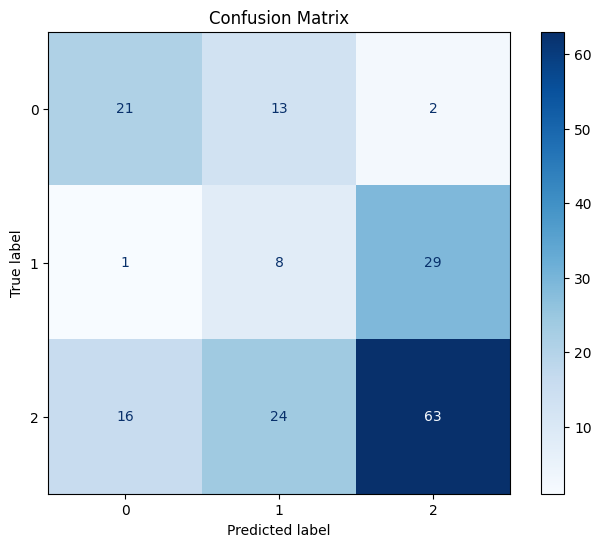


 XGBOOST DECISION TREE


/home/c/Desktop/AI_MUAR/ai_f1/.venv/lib/python3.13/site-packages/xgboost/plotting.py:268: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(


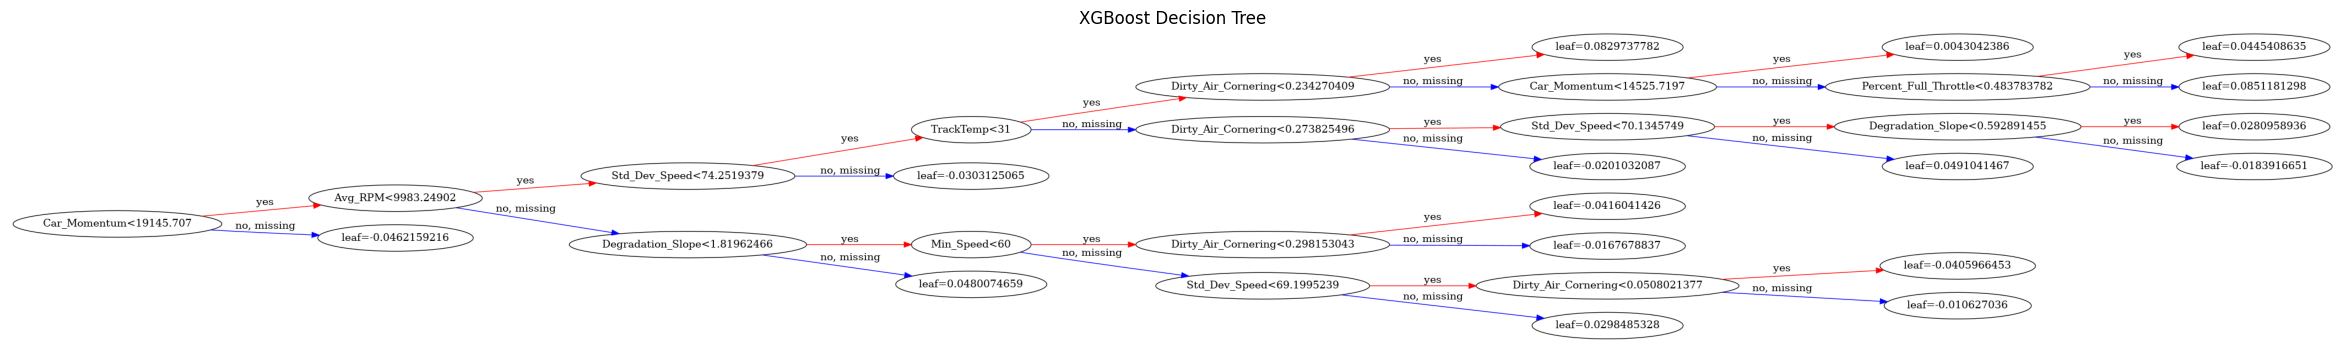


 SHAP INTERPRETABILITY


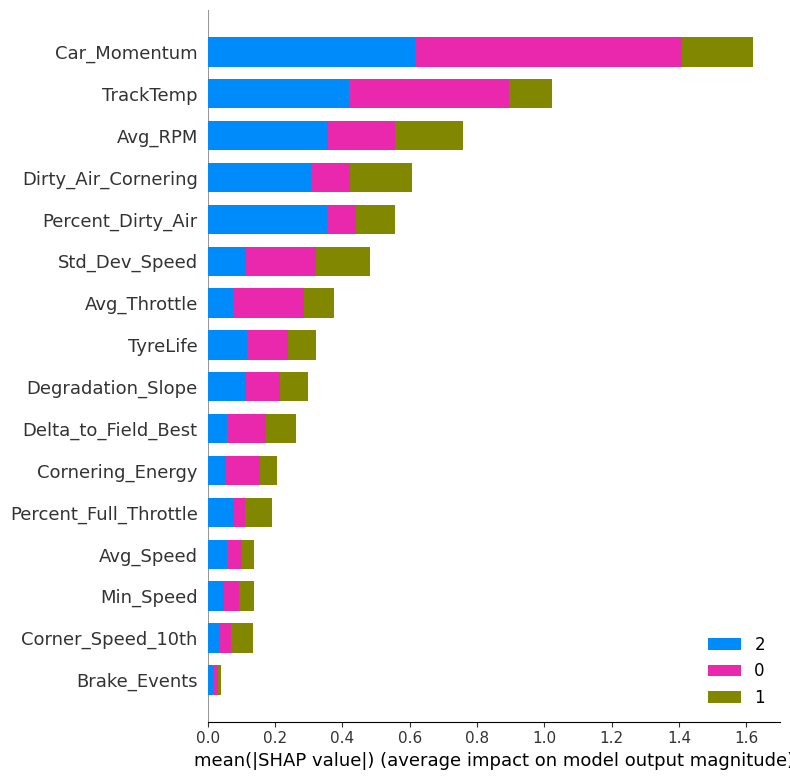

In [12]:
######################################################### EVALUATION ##############################################

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import shap
import matplotlib.pyplot as plt

# EVALUATE ON 20% HOLDOUT
y_pred = final_model.predict(X_test)
print(classification_report(y_test, y_pred))

target_names = final_model.classes_

print("\n CONFUSION MATRIX")
cm_strict = confusion_matrix(y_test, y_pred)
disp_strict = ConfusionMatrixDisplay(confusion_matrix=cm_strict, display_labels=target_names)

fig, ax = plt.subplots(figsize=(8, 6))
disp_strict.plot(cmap='Blues', ax=ax)
plt.title("Confusion Matrix")
plt.show()

print("\n XGBOOST DECISION TREE")
final_model.get_booster().feature_names = list(X_train.columns)
fig, ax = plt.subplots(figsize=(30, 15)) 
xgb.plot_tree(final_model, num_trees=0, ax=ax, rankdir='LR')
plt.title("XGBoost Decision Tree")
plt.show()

print("\n SHAP INTERPRETABILITY")
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(
    shap_values, 
    X_test, 
    class_names=target_names, 
    plot_type="bar", 
    show=True
)